<a href="https://colab.research.google.com/github/eliasdengo/Python-practice-from-beginning-to-advance/blob/Eliasrepos/Movies_Recommendation_System_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

import dependency

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from wordcloud import WordCloud
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

data processing

In [4]:
df=pd.read_csv('/content/sample_data/movies.csv')
df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [5]:
df.shape

(4803, 20)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

In [7]:
df.isnull().sum()

,0
budget,0
genres,0
homepage,3091
id,0
keywords,0
original_language,0
original_title,0
overview,3
popularity,0
production_companies,0


In [8]:
# i want to remove column
df=df.drop(columns='homepage')

In [11]:
# i want select overview then remove overview row data which is null
df=df[df['overview'].notnull()].reset_index(drop=True)

In [12]:
df.isnull().sum()

,0
budget,0
genres,0
id,0
keywords,0
original_language,0
original_title,0
overview,0
popularity,0
production_companies,0
production_countries,0


In [13]:
movie_data=['genres','keywords','overview','title']
df=df[movie_data]

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4800 entries, 0 to 4799
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   genres    4800 non-null   object
 1   keywords  4800 non-null   object
 2   overview  4800 non-null   object
 3   title     4800 non-null   object
dtypes: object(4)
memory usage: 150.1+ KB


In [21]:
df.shape

(4800, 5)

In [41]:
df['combined']=df['genres'] + " " +df['keywords']+ " " +df['overview']

In [42]:
df.head()

,genres,keywords,overview,title,combined
0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","In the 22nd century, a paraplegic Marine is di...",Avatar,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam..."
1,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","Captain Barbossa, long believed to be dead, ha...",Pirates of the Caribbean: At World's End,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""..."
2,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",A cryptic message from Bond’s past sends him o...,Spectre,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam..."
3,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",Following the death of District Attorney Harve...,The Dark Knight Rises,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam..."
4,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","John Carter is a war-weary, former military ca...",John Carter,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam..."


In [43]:
data = df[['title','combined']]

In [44]:
data.head()

,title,combined
0,Avatar,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam..."
1,Pirates of the Caribbean: At World's End,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""..."
2,Spectre,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam..."
3,The Dark Knight Rises,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam..."
4,John Carter,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam..."


In [45]:
data.shape

(4800, 2)

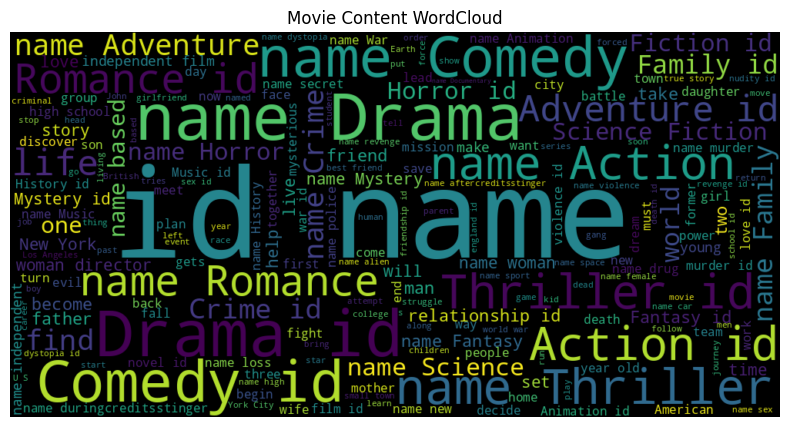

In [46]:
# movie content in wordcloud
text = ' '.join(data['combined'])
wordcloud=WordCloud(width=1000,height=500).generate(text)
plt.figure(figsize=(15,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.title('Movie Content WordCloud')
plt.show()


In [47]:
# download nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [48]:
stop_words=set(stopwords.words('english'))


In [54]:
def preprocess_text(text):
  text=re.sub(r'[^a-zA-Z\s]','',text)
  text=text.lower()
  tokens=word_tokenize(text)
  filtered_tokens=[word for word in tokens if word not in stop_words]
  return ' '.join(filtered_tokens)

In [55]:
# apply processing in move content
data['clear_text']=df['combined'].apply(preprocess_text)

/tmp/ipykernel_1982/3858000210.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['clear_text']=df['combined'].apply(preprocess_text)


In [56]:
data.head()

,title,combined,clear_text
0,Avatar,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",id name action id name adventure id name fanta...
1,Pirates of the Caribbean: At World's End,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",id name adventure id name fantasy id name acti...
2,Spectre,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",id name action id name adventure id name crime...
3,The Dark Knight Rises,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",id name action id name crime id name drama id ...
4,John Carter,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",id name action id name adventure id name scien...


In [57]:
# vectorize using tfidf
tfidf_vectorizer=TfidfVectorizer(max_features=5000)
tfidf_matrix=tfidf_vectorizer.fit_transform(data['clear_text'])


In [58]:
# compute cosine similarity
cosine_sim=cosine_similarity(tfidf_matrix,tfidf_matrix)

In [59]:
print(cosine_sim)

[[1.         0.41530577 0.25789976 ... 0.22800817 0.00355942 0.10904648]
 [0.41530577 1.         0.25754715 ... 0.22752018 0.         0.10431593]
 [0.25789976 0.25754715 1.         ... 0.14477425 0.         0.06537689]
 ...
 [0.22800817 0.22752018 0.14477425 ... 1.         0.01636546 0.08544596]
 [0.00355942 0.         0.         ... 0.01636546 1.         0.00522219]
 [0.10904648 0.10431593 0.06537689 ... 0.08544596 0.00522219 1.        ]]


In [71]:
# recommendation function
def Recommendation_movies(movie_names,cosine_sim=cosine_sim,df=data,top_n=5):

  index_of_movies = df[df['title'].str.lower()==movie_names.lower()].index
  if len(index_of_movies) == 0:
    return "Movie not found in the dataset."
  index_of_movies = index_of_movies[0]

  # get similarity score
  similarity_scores = list(enumerate(cosine_sim[index_of_movies]))
  similarity_scores = sorted(similarity_scores,key=lambda x:x[1],reverse=True)
  similarity_scores = similarity_scores[1:top_n+1]

  #
  movie_indices = [i[0] for i in similarity_scores]
  recommended_movies = df['title'].iloc[movie_indices]
  return recommended_movies


In [72]:
data['title']

,title
0,Avatar
1,Pirates of the Caribbean: At World's End
2,Spectre
3,The Dark Knight Rises
4,John Carter
...,...
4795,El Mariachi
4796,Newlyweds
4797,"Signed, Sealed, Delivered"
4798,Shanghai Calling


In [73]:
#row_index=df[df['title']=='El Mariachi'].index
row_index=df[df['title']=='My Date with Drew'].index
print(row_index)

Index([4799], dtype='int64')


In [75]:
# Example Recommendation
recommendation = Recommendation_movies('Avatar')
print(recommendation)

2403                                  Aliens
1079                                    Dune
838                                   Alien³
95                              Interstellar
1068    The Hitchhiker's Guide to the Galaxy
Name: title, dtype: object
